In [54]:
!pip install -q sentence-transformers scikit-learn pandas matplotlib seaborn

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

df = pd.read_csv(
    "gutenberg_books.csv",
    dtype={"book_id": str}
)

df["num_caracteres"] = df["tokens_clean"].str.len()

print(df["num_caracteres"].describe())

print(df[["book_id", "num_caracteres"]].sort_values(
    "num_caracteres",
    ascending=False
).head(10))

modelo = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = modelo.encode(
    df["tokens_clean"].tolist(),
    show_progress_bar=True
)

print("Formato dos embeddings:", embeddings.shape)


count    3.120000e+02
mean     3.187517e+05
std      2.824907e+05
min      1.883300e+04
25%      1.084275e+05
50%      2.561775e+05
75%      4.073928e+05
max      1.717953e+06
Name: num_caracteres, dtype: float64
    book_id  num_caracteres
189     967         1717953
93      968         1708388
146    1946         1449145
78      820         1444627
288     917         1270643
266    1860         1241739
143    2158         1222354
214     840         1203775
299    1586         1165699
239     452         1097117


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Formato dos embeddings: (312, 384)


In [56]:
resultados_k = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(embeddings)

    score = silhouette_score(
        embeddings,
        labels
    )

    resultados_k.append({
        "k": k,
        "silhouette": score
    })

resultados_k = pd.DataFrame(resultados_k)

resultados_k

,k,silhouette
0,2,0.101052
1,3,0.090338
2,4,0.106723
3,5,0.100180
4,6,0.085856
5,7,0.076581
6,8,0.067257
7,9,0.068552
8,10,0.063273


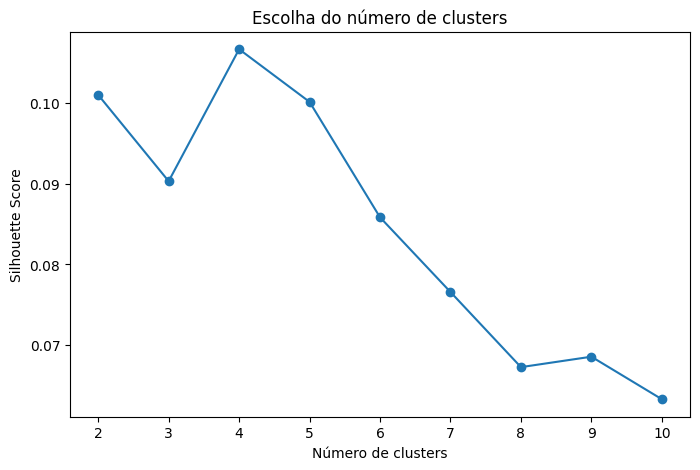

In [57]:
plt.figure(figsize=(8, 5))

plt.plot(
    resultados_k["k"],
    resultados_k["silhouette"],
    marker="o"
)

plt.xlabel("Número de clusters")
plt.ylabel("Silhouette Score")
plt.title("Escolha do número de clusters")

plt.show()

In [58]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(embeddings)

df["cluster"] = clusters

print(df["cluster"].value_counts().sort_index())

cluster
0     18
1    107
2    115
3     72
Name: count, dtype: int64


In [59]:
pca = PCA(n_components=2)

embeddings_2d = pca.fit_transform(embeddings)

print(embeddings_2d.shape)

(312, 2)


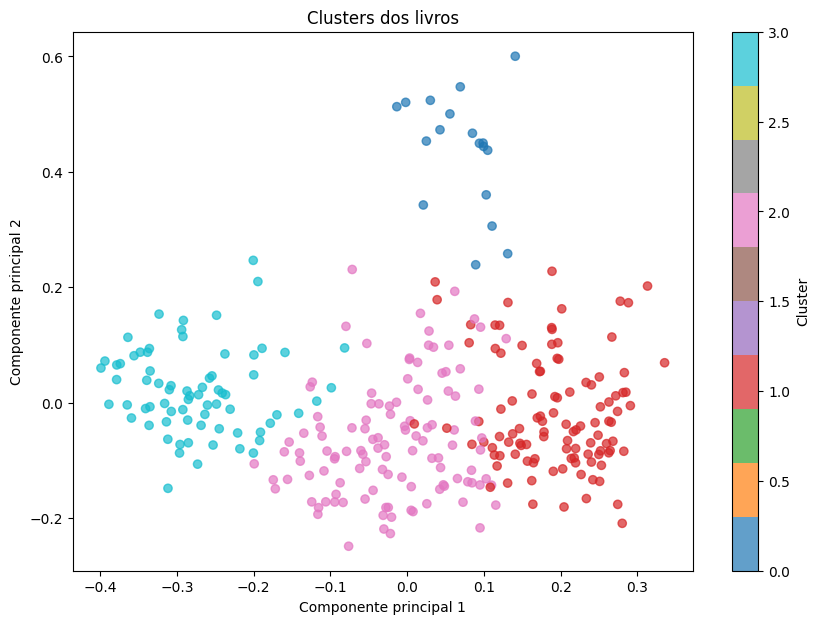

In [60]:
plt.figure(figsize=(10, 7))

plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=df["cluster"],
    cmap="tab10",
    alpha=0.7
)

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Clusters dos livros")

plt.colorbar(label="Cluster")

plt.show()

In [61]:
def buscar(consulta, quantidade=10):

    embedding_consulta = modelo.encode(
        [consulta]
    )

    similaridades = cosine_similarity(
        embedding_consulta,
        embeddings
    ).flatten()

    indices = similaridades.argsort()[::-1]

    resultados = df.iloc[
        indices[:quantidade]
    ].copy()

    resultados["similaridade"] = (
        similaridades[indices[:quantidade]]
    )

    return resultados

In [62]:
resultados = buscar(
    "love romance",
    quantidade=10
)

resultados[
    ["book_id", "cluster", "similaridade"]
]

,book_id,cluster,similaridade
214,840,2,0.314436
181,1848,2,0.295613
148,1714,2,0.287744
177,1994,1,0.284661
308,1729,2,0.280489
185,1562,2,0.279314
102,2597,2,0.277974
42,2453,2,0.277944
153,2457,2,0.271138
111,2135,2,0.267487


In [75]:
resultados = buscar(
    "war politics",
    quantidade=10
)

resultados[
    ["book_id", "cluster", "similaridade"]
]

,book_id,cluster,similaridade
105,1804,2,0.447183
163,1590,2,0.242737
0,71,2,0.218773
264,2194,3,0.213898
253,1817,2,0.212540
194,1887,2,0.205017
54,2026,3,0.202044
287,947,2,0.201893
167,1560,2,0.196026
129,1821,2,0.193395


In [74]:
resultados = buscar(
    "religion morality",
    quantidade=10
)

resultados[
    ["book_id", "cluster", "similaridade"]
]

,book_id,cluster,similaridade
77,2330,2,0.250657
151,2076,3,0.201595
286,1689,3,0.199685
282,2373,2,0.182317
0,71,2,0.178512
86,908,2,0.174290
277,1911,2,0.171321
30,2124,3,0.167030
194,1887,2,0.157024
114,430,2,0.149002


In [65]:
resultados["cluster"].value_counts().sort_index()

,count
cluster,
0,4
1,2
2,8
3,6


In [66]:
def buscar_no_cluster(
    consulta,
    cluster,
    quantidade=10
):

    indices_cluster = df[
        df["cluster"] == cluster
    ].index

    embeddings_cluster = embeddings[
        indices_cluster
    ]

    embedding_consulta = modelo.encode(
        [consulta]
    )

    similaridades = cosine_similarity(
        embedding_consulta,
        embeddings_cluster
    ).flatten()

    ordem = similaridades.argsort()[::-1]

    indices_selecionados = indices_cluster[
        ordem[:quantidade]
    ]

    resultados = df.loc[
        indices_selecionados
    ].copy()

    resultados["similaridade"] = (
        similaridades[ordem[:quantidade]]
    )

    return resultados

In [67]:
resultados = buscar_no_cluster(
    "religion morality",
    cluster=2,
    quantidade=10
)

resultados[
    ["book_id", "cluster", "similaridade"]
]

,book_id,cluster,similaridade
77,2330,2,0.250657
282,2373,2,0.182317
0,71,2,0.178512
86,908,2,0.174290
277,1911,2,0.171321
194,1887,2,0.157024
114,430,2,0.149002
127,2084,2,0.145099
155,1930,2,0.134904
233,2130,2,0.132734
